## Overview
This is the monthly waste collection tonnage data from the New York City
Department of Sanitation (DSNY), dating back to the 1990s. The collection
data is broken down by borough and community district.

## Data Dictionary
- **REFUSETONSCOLLECTED**: Tons of general refuse/trash collected
- **PAPERTONSCOLLECTED**: Tons of paper recycling collected
- **MGPTONSCOLLECTED**: Tons of metal/glass/plastic recycling collected
- **RESORGANICSTONS**: Tons of residential organics collected
- **SCHOOLORGANICTONS**: Tons of school organics collected
- **LEAVESORGANICTONS**: Tons of leaves collected
- **XMASTREETONS**: Tons of Christmas trees collected
- **OTHERORGANICSTONS**: Tons of other organics collected

In [94]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the data
df = pd.read_csv('DSNY_Monthly_Tonnage_Data_20260320.csv')

# Look at the data
df.head()

,MONTH,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,PAPERTONSCOLLECTED,MGPTONSCOLLECTED,RESORGANICSTONS,SCHOOLORGANICTONS,LEAVESORGANICTONS,XMASTREETONS,OTHERORGANICSTONS,BOROUGH_ID
0,2026 / 02,Bronx,1,2879.8,200.3,109.8,16.2,55.7,NaN,NaN,NaN,2
1,2026 / 02,Bronx,2,6520.9,224.2,154.8,13.4,55.7,NaN,NaN,NaN,2
2,2026 / 02,Bronx,3,1971.3,107.5,116.1,12.8,NaN,NaN,NaN,NaN,2
3,2026 / 02,Bronx,4,3610.0,199.9,226.5,11.9,42.7,NaN,NaN,0.5,2
4,2026 / 02,Bronx,5,3085.9,185.3,246.1,12.1,49.4,NaN,NaN,NaN,2


In [95]:
# Numerical columns, bad/missing values turn into NaN
numerical_cols = [
    'REFUSETONSCOLLECTED', 
    'PAPERTONSCOLLECTED', 
    'MGPTONSCOLLECTED',
    'RESORGANICSTONS', 
    'SCHOOLORGANICTONS', 
    'LEAVESORGANICTONS',
    'XMASTREETONS',
    'OTHERORGANICSTONS'
]

for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Categorical columns
categorical_cols = [
    'BOROUGH', 
    'COMMUNITYDISTRICT', 
    'BOROUGH_ID'
]


--- REFUSETONSCOLLECTED ---
Min:    8.4
Max:    10413.9
Mean:   4239.24
Median: 4062.20
Outliers: 293 values outside [23.18, 8298.97]


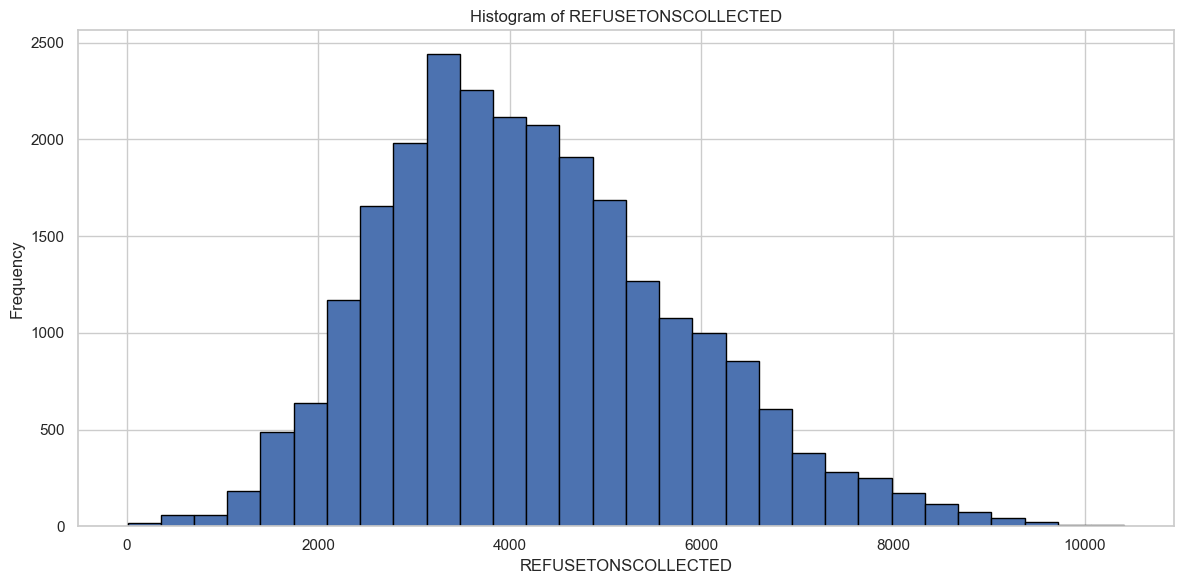


--- PAPERTONSCOLLECTED ---
Min:    0.0
Max:    2129.7
Mean:   447.80
Median: 398.90
Outliers: 777 values outside [-230.30, 1072.10]


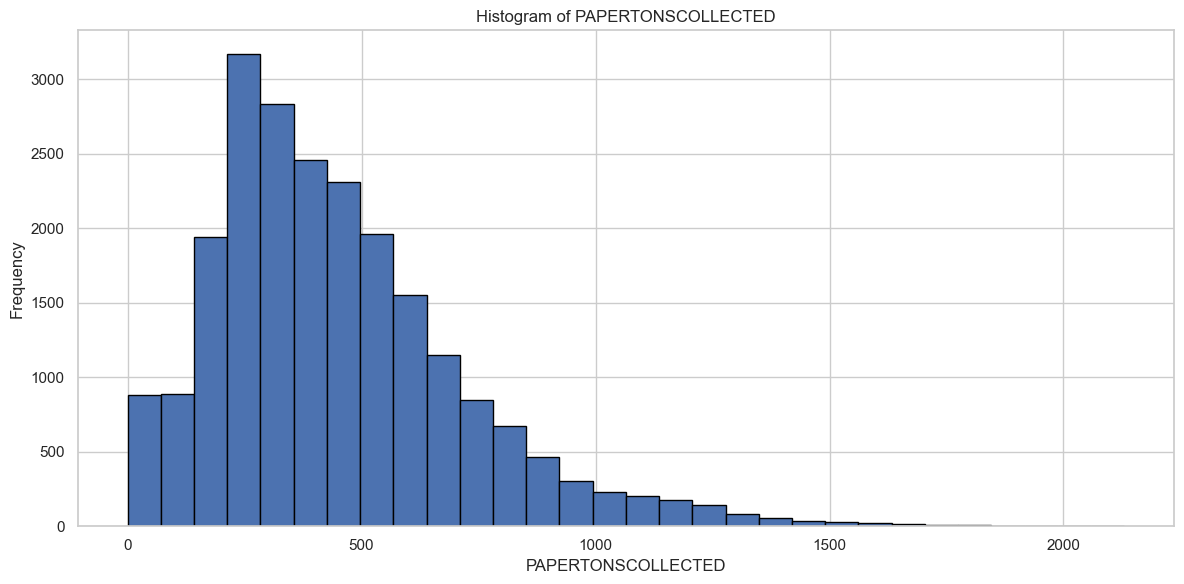


--- MGPTONSCOLLECTED ---
Min:    0.0
Max:    1254.6
Mean:   353.39
Median: 333.75
Outliers: 308 values outside [-130.54, 810.16]


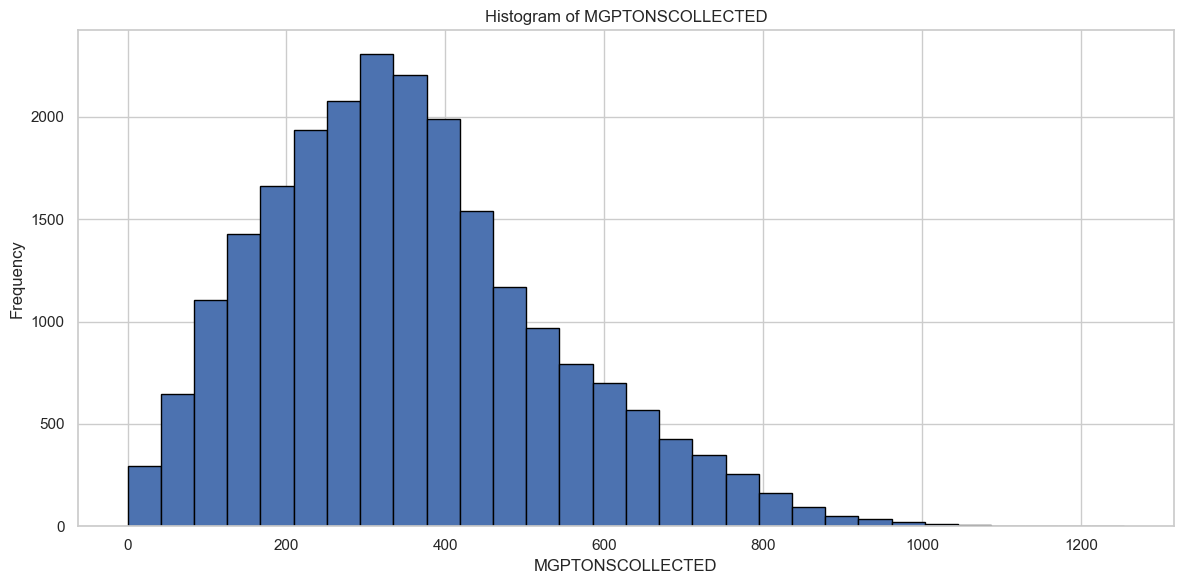


--- RESORGANICSTONS ---
Min:    0.4
Max:    785.5
Mean:   88.83
Median: 61.30
Outliers: 193 values outside [-103.68, 246.53]


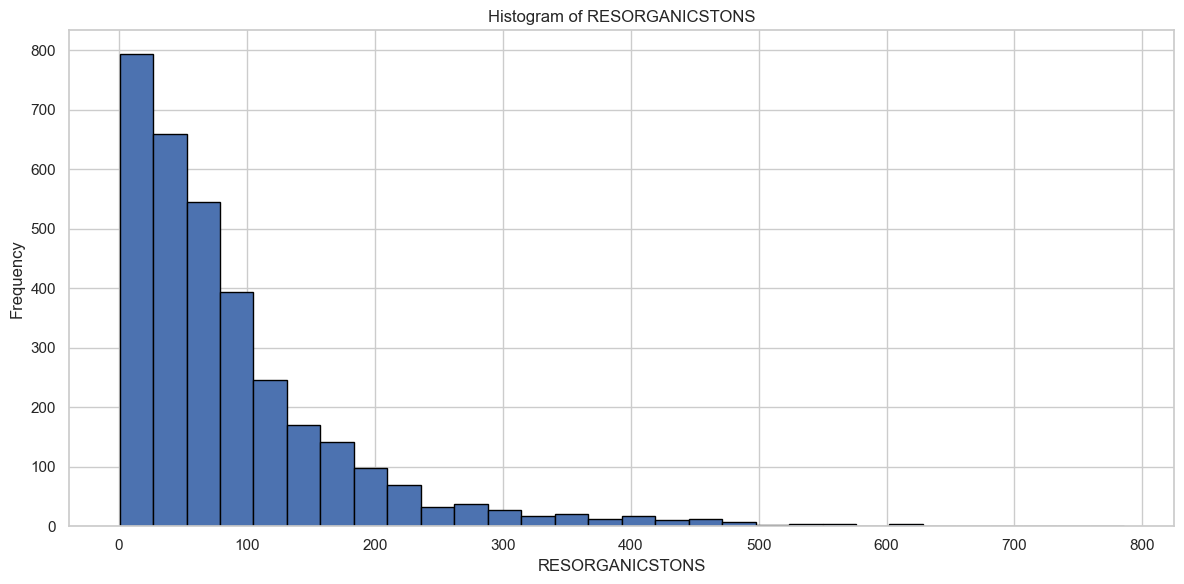


--- SCHOOLORGANICTONS ---
Min:    0.1
Max:    265.7
Mean:   53.73
Median: 42.90
Outliers: 122 values outside [-33.07, 130.32]


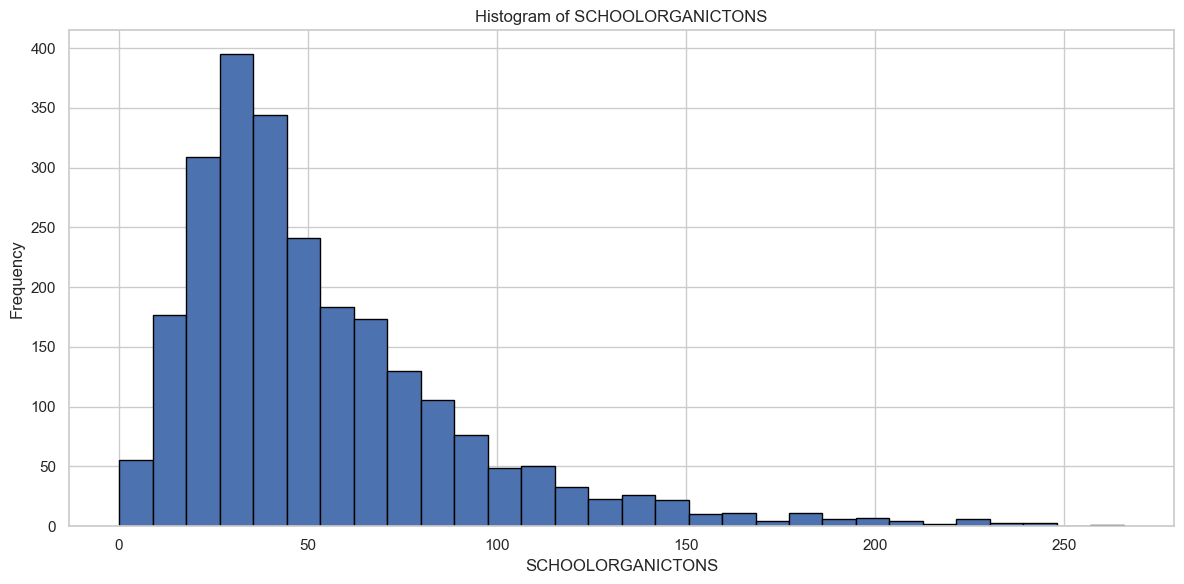


--- LEAVESORGANICTONS ---
Min:    0.6
Max:    996.2
Mean:   133.50
Median: 52.30
Outliers: 66 values outside [-226.78, 410.63]


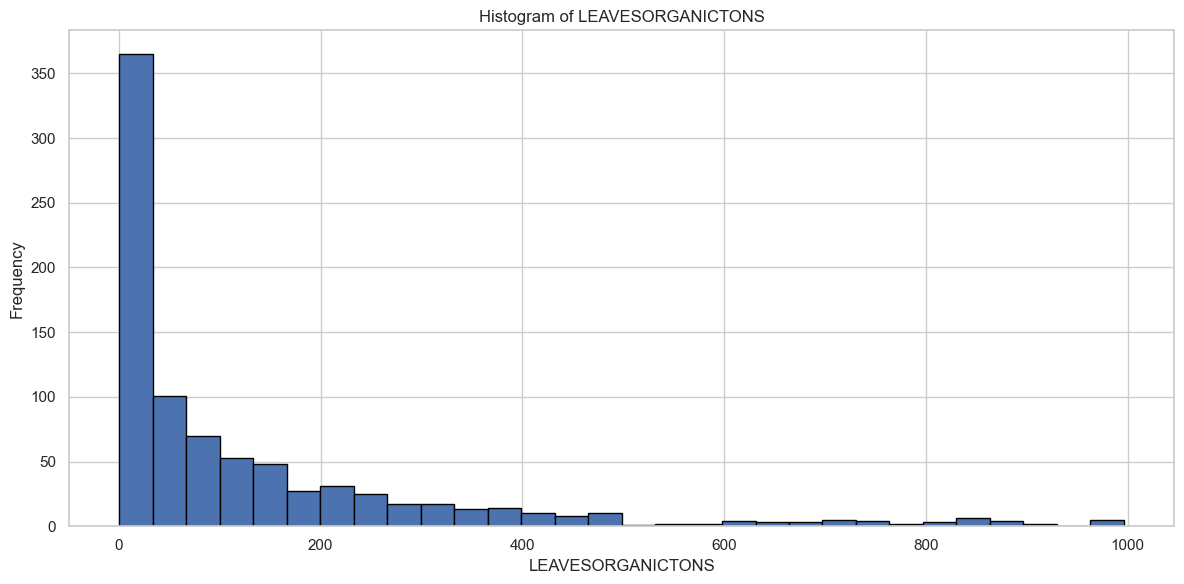


--- XMASTREETONS ---
Min:    0.4
Max:    186.0
Mean:   26.27
Median: 18.00
Outliers: 94 values outside [-28.65, 73.35]


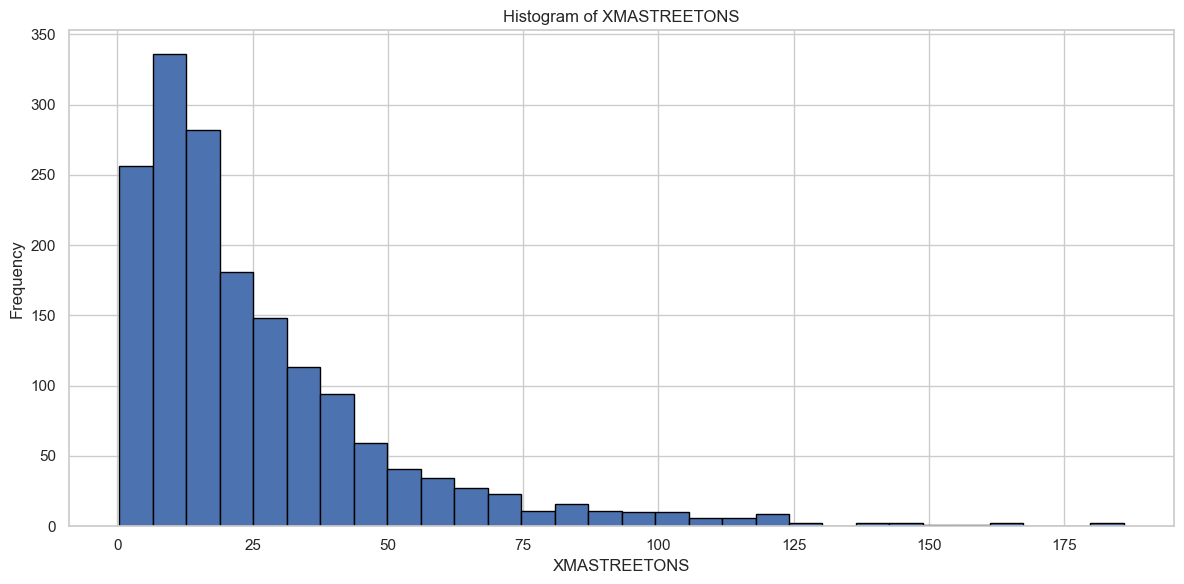


--- OTHERORGANICSTONS ---
Min:    0.0
Max:    490.6
Mean:   12.55
Median: 9.10
Outliers: 82 values outside [-10.90, 29.90]


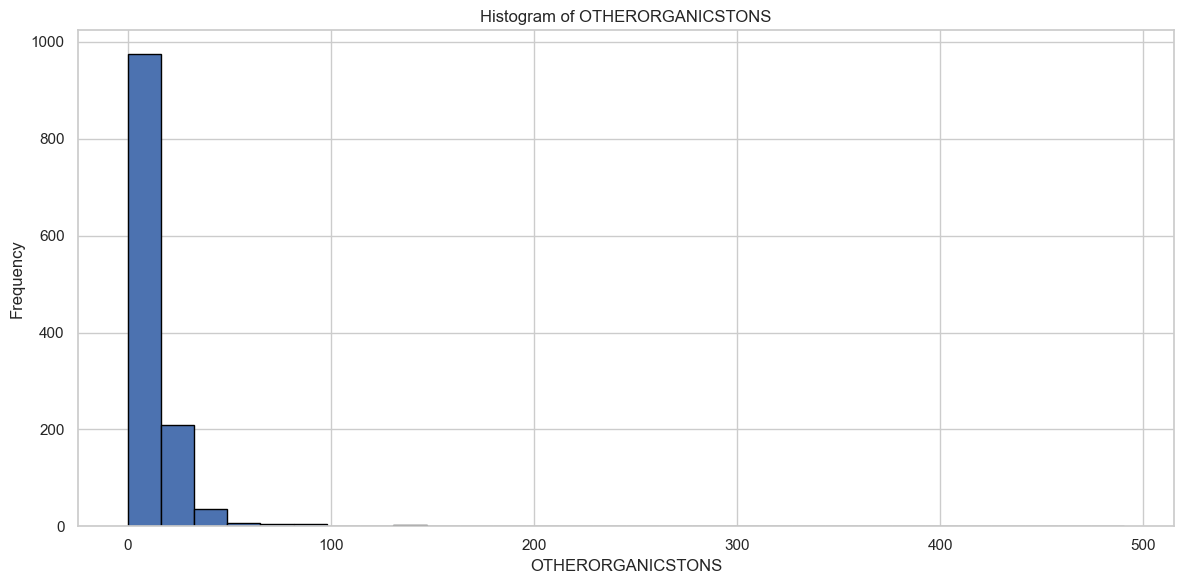

In [96]:
for col in numerical_cols:
    fig, ax = plt.subplots()
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    
    # Print summary statistics
    print(f"\n--- {col} ---")
    print(f"Min:    {df[col].min()}")
    print(f"Max:    {df[col].max()}")
    print(f"Mean:   {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    
    # Identify outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers: {len(outliers)} values outside [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    plt.tight_layout()
    plt.show()

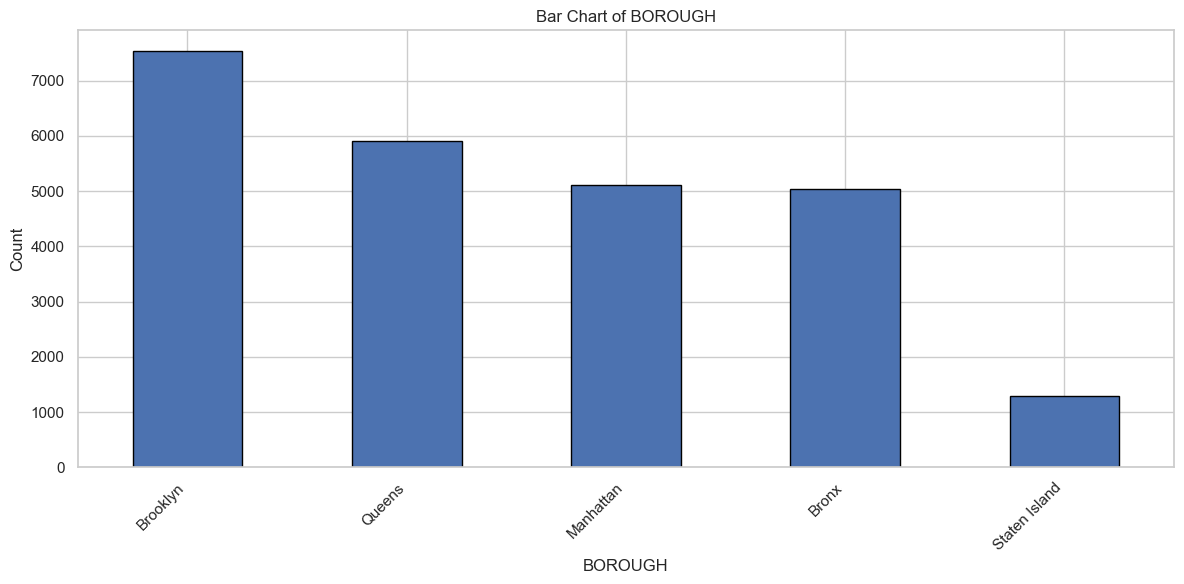

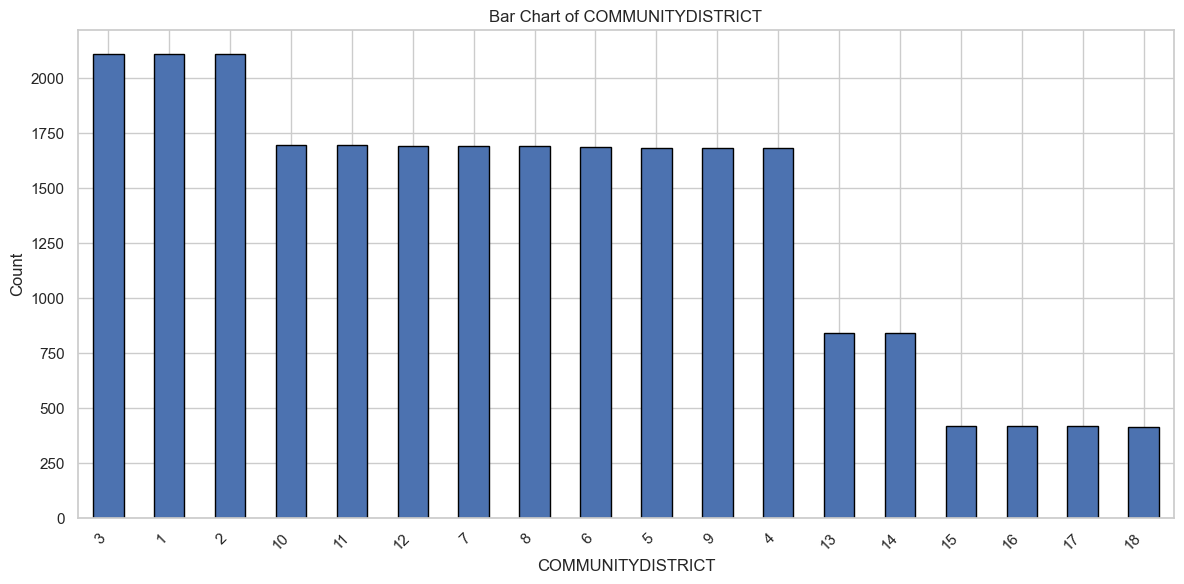

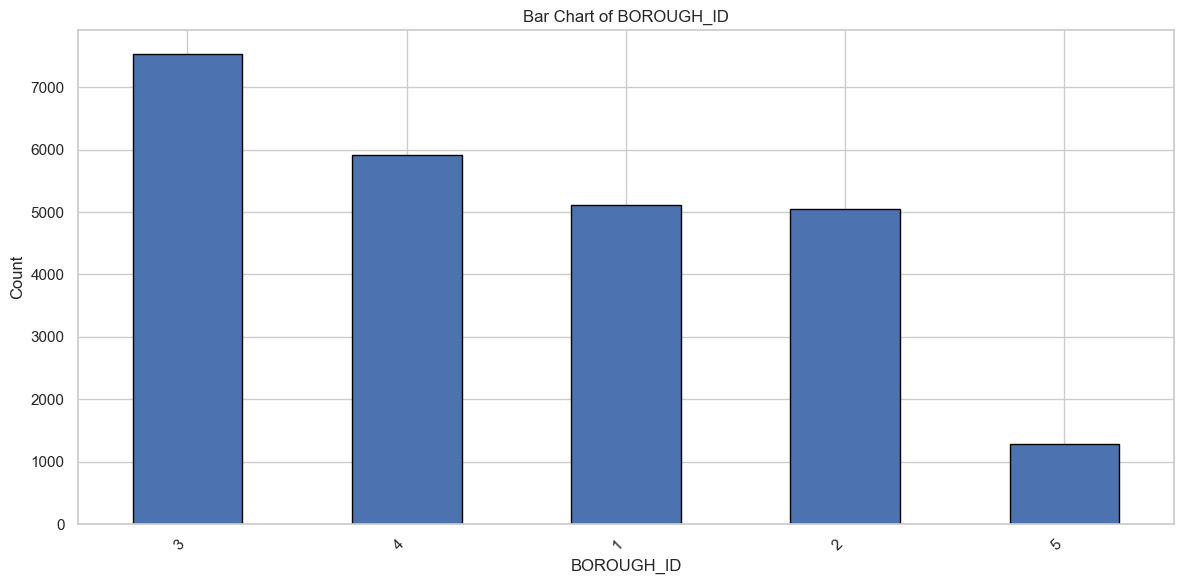

In [97]:
for col in categorical_cols:
    fig, ax = plt.subplots()
    df[col].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'Bar Chart of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

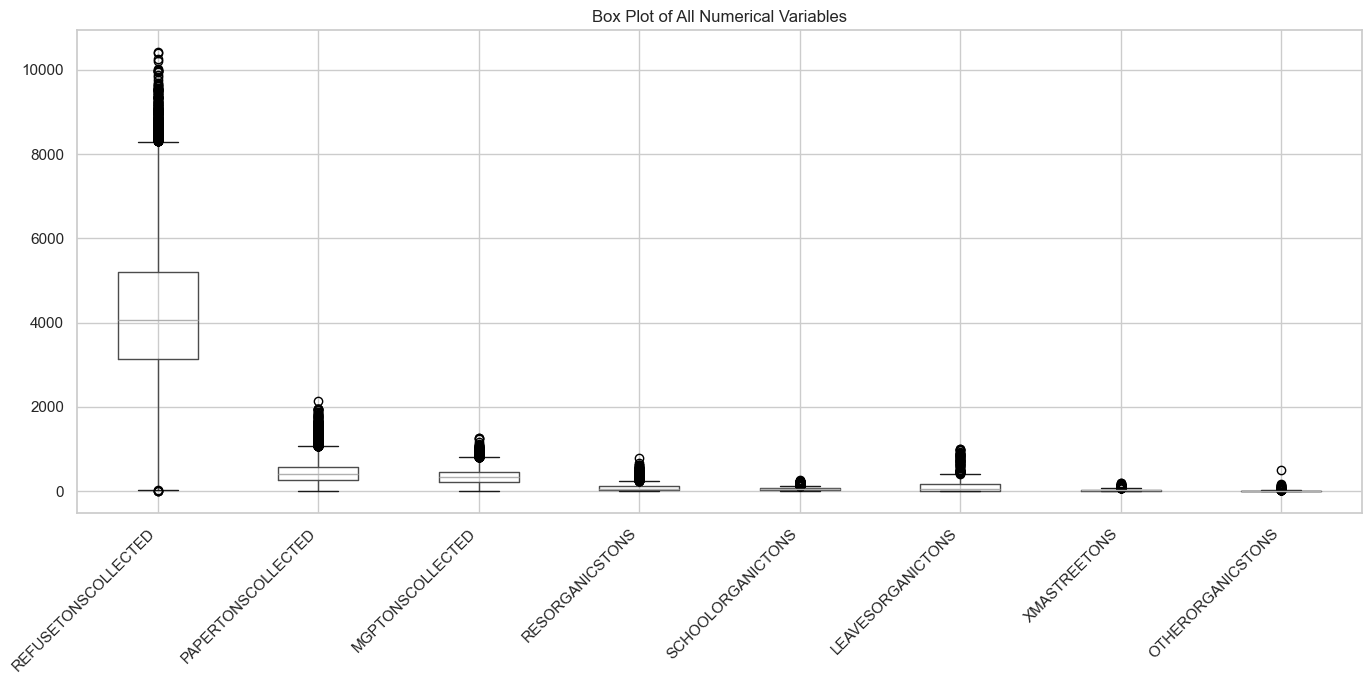

In [98]:
fig, ax = plt.subplots(figsize=(14, 7))
df[numerical_cols].boxplot(ax=ax)
ax.set_title('Box Plot of All Numerical Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Combined Box Plot Observations

The box plot reveals that **REFUSETONSCOLLECTED** operate on a much
larger scale than the other variables. The other columns
(RESORGANICSTONS, SCHOOLORGANICTONS, etc.) are compressed near zero,
making them hard to compare visually at this scale.

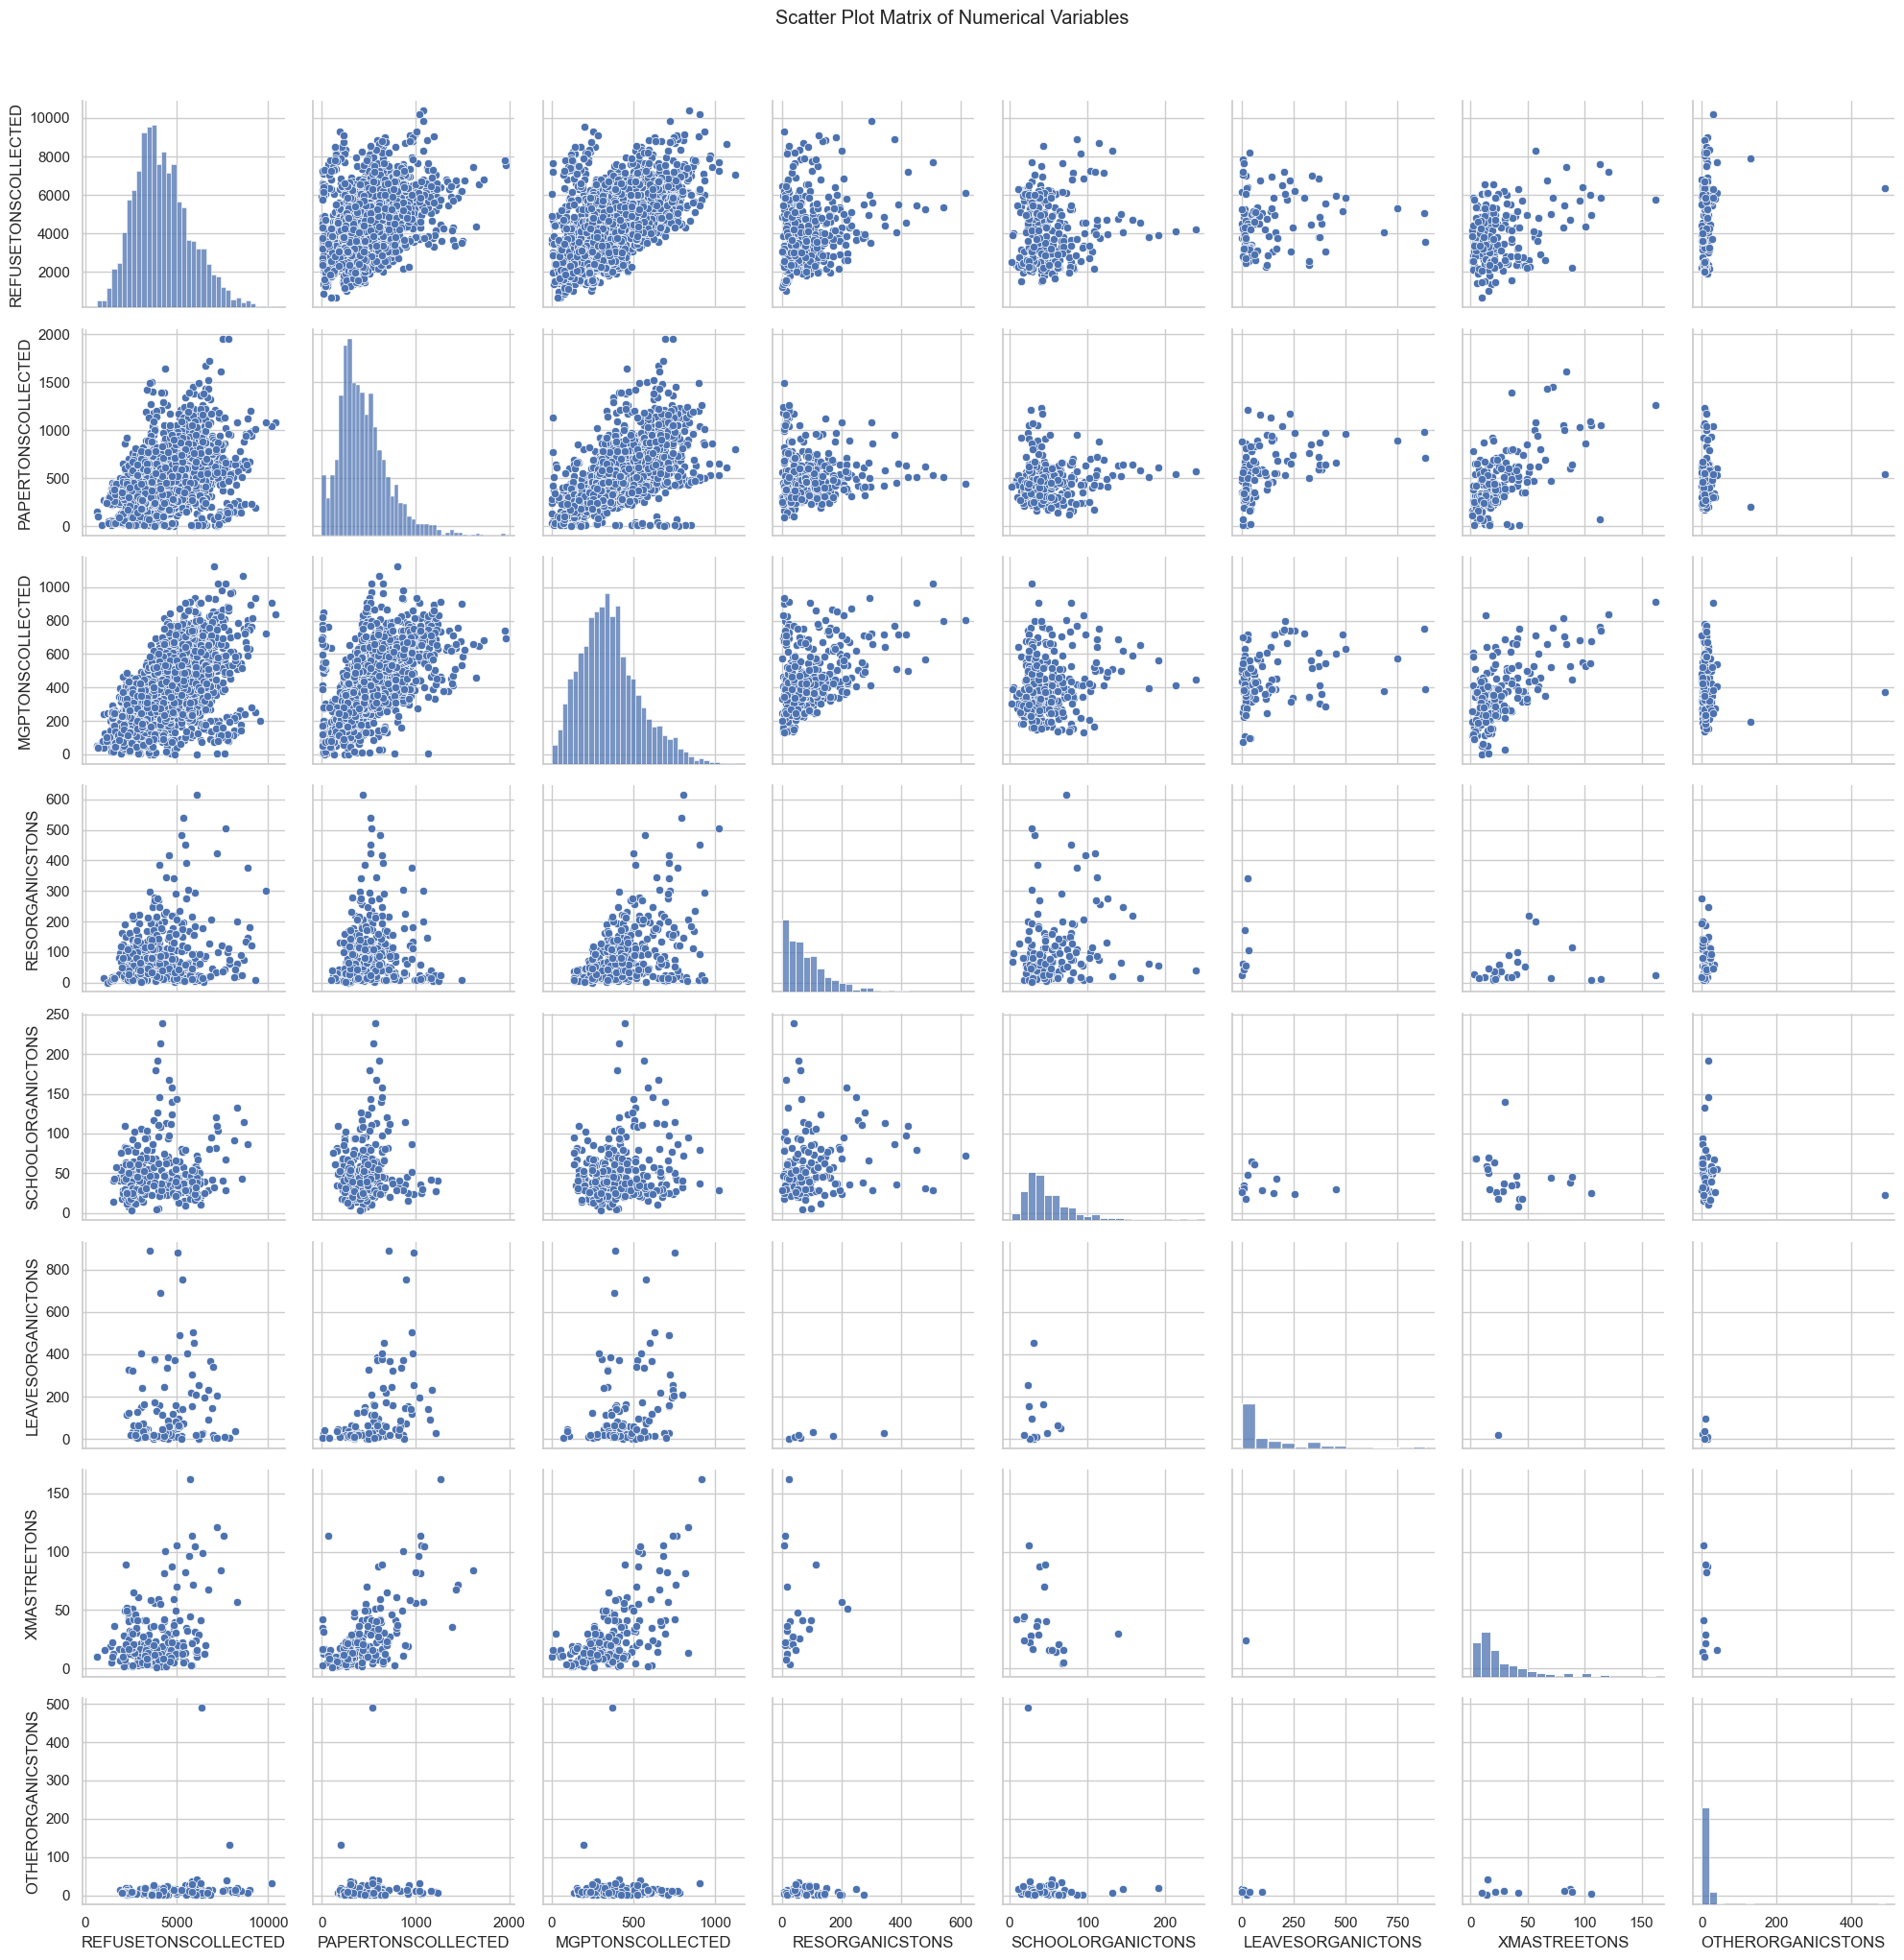

In [99]:
# df.sample(3000) since it took a while with 24k rows
sns.pairplot(df[numerical_cols].sample(3000, random_state=42))
plt.suptitle('Scatter Plot Matrix of Numerical Variables', y=1.02)
plt.tight_layout()
plt.show()

## Pairwise Relationships

The scatter plot matrix reveals:
- A **positive correlation** between REFUSETONSCOLLECTED and 
  PAPERTONSCOLLECTED, districts producing more trash also recycle 
  more paper.
- Most organics variables show **weak or no correlation** with refuse, 
  likely due to the organics program being newer and not universal.

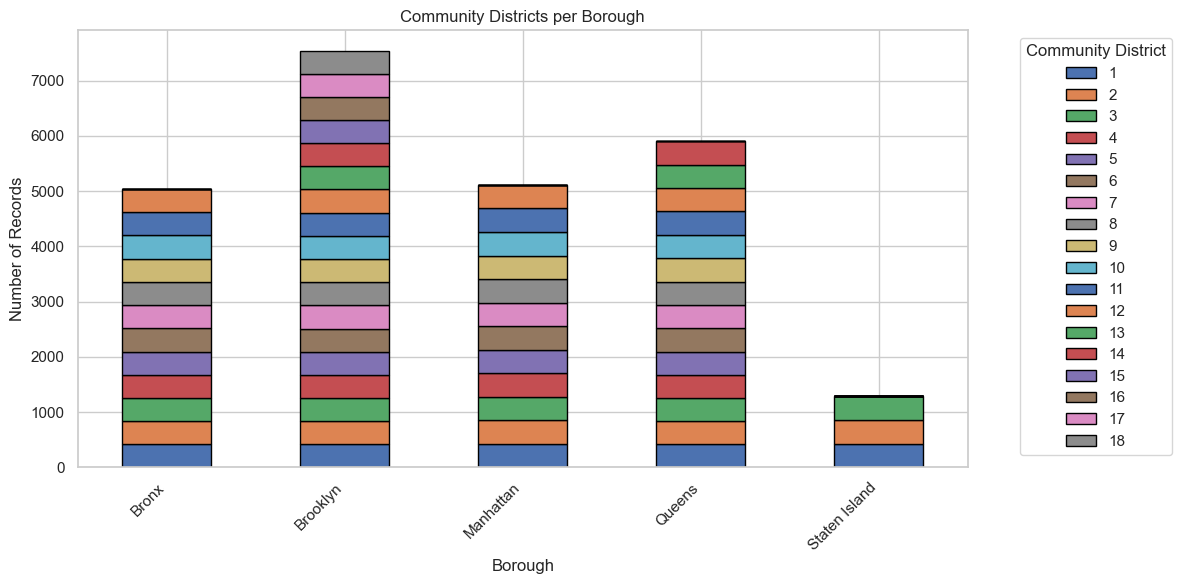

In [100]:
# Borough vs Community District
fig, ax = plt.subplots(figsize=(12, 6))
ct = df.groupby(['BOROUGH', 'COMMUNITYDISTRICT']).size().unstack(fill_value=0)
ct.plot(kind='bar', stacked=True, ax=ax, edgecolor='black')
ax.set_title('Community Districts per Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Number of Records')
ax.legend(title='Community District', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Categorical vs Categorical: Borough vs Community District

The stacked bar chart shows the relationship between Borough and 
Community District. Brooklyn has the most community districts (18), 
followed by Queens (14), then Manhattan (12), with Staten Island
having the fewest (3). Each district contributes roughly the same
number of records (~400), indicating consistent monthly reporting
across all districts over the dataset's time span. Therefore, the total
bar height is proportional to the number of districts in each borough.

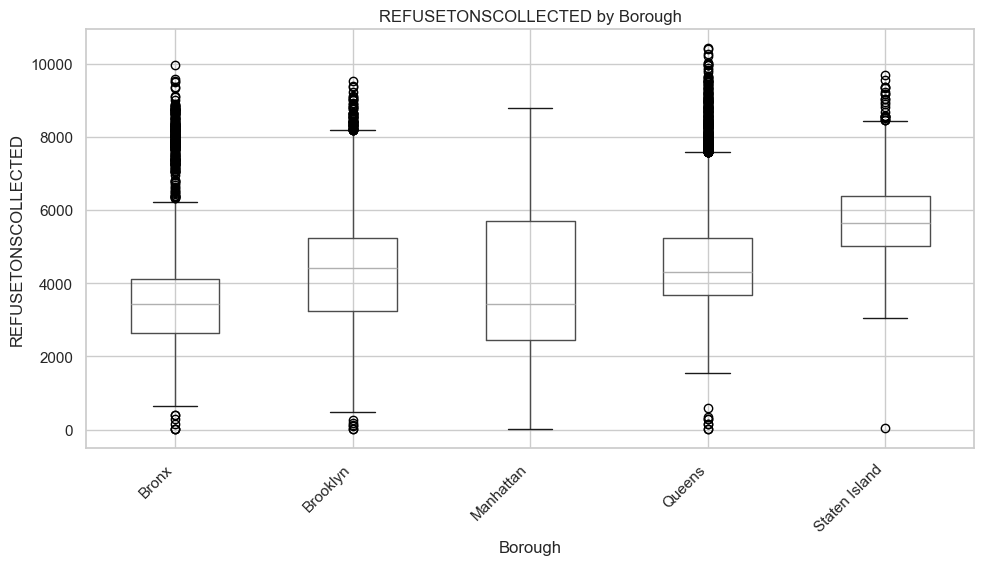

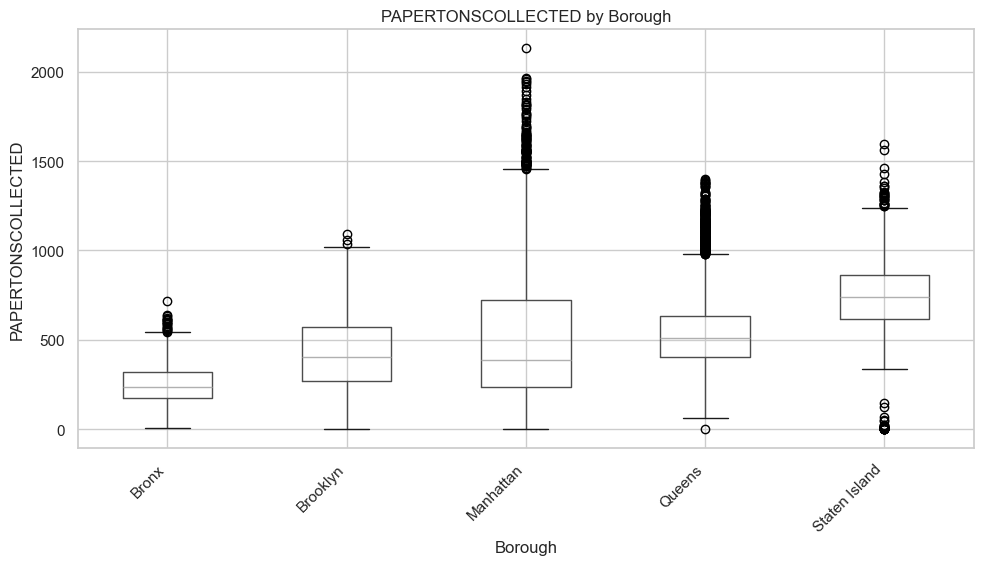

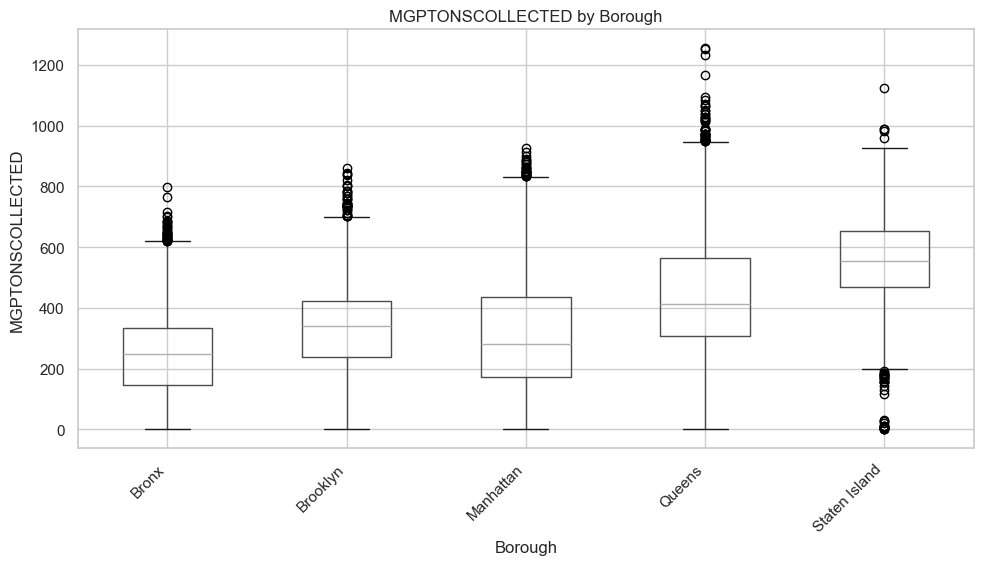

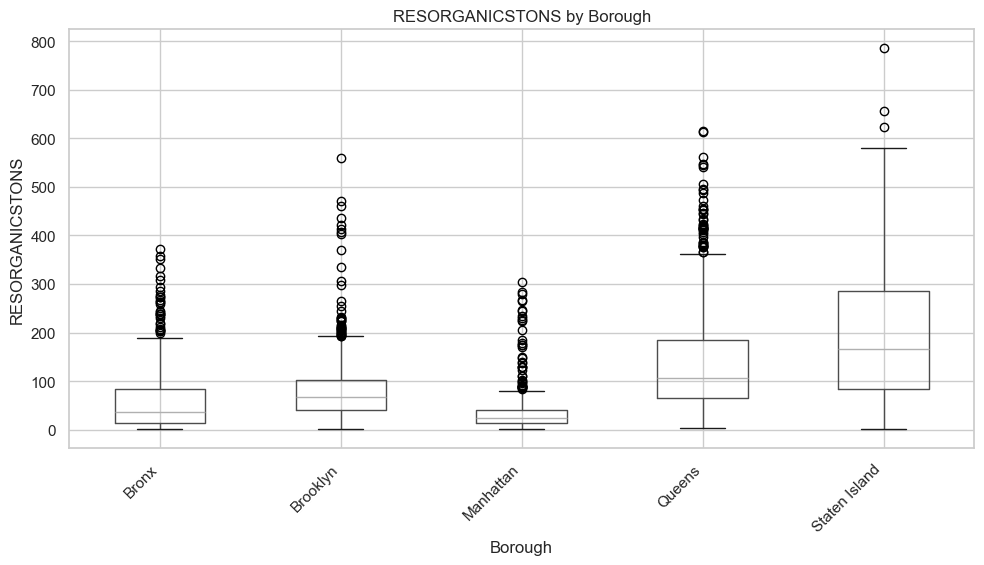

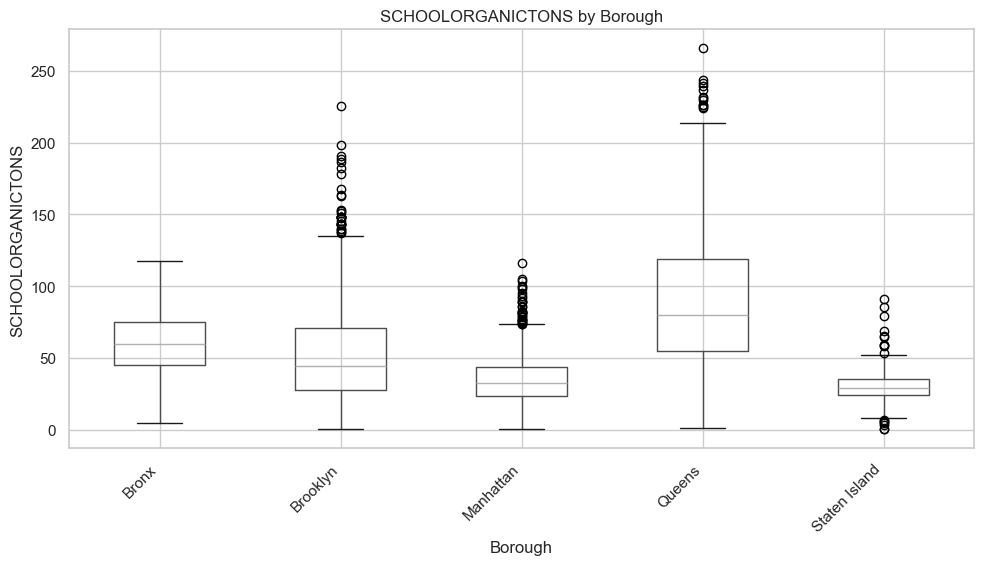

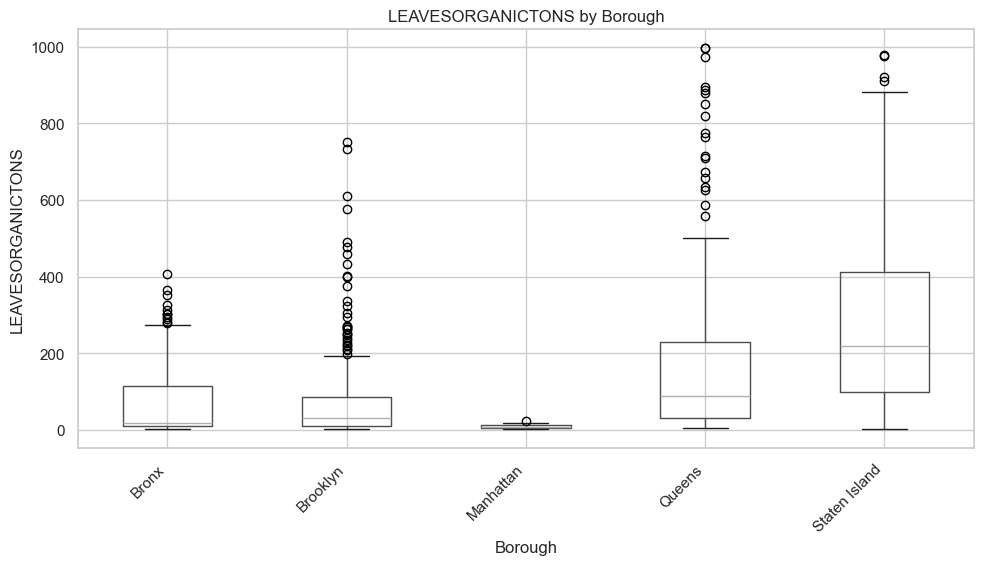

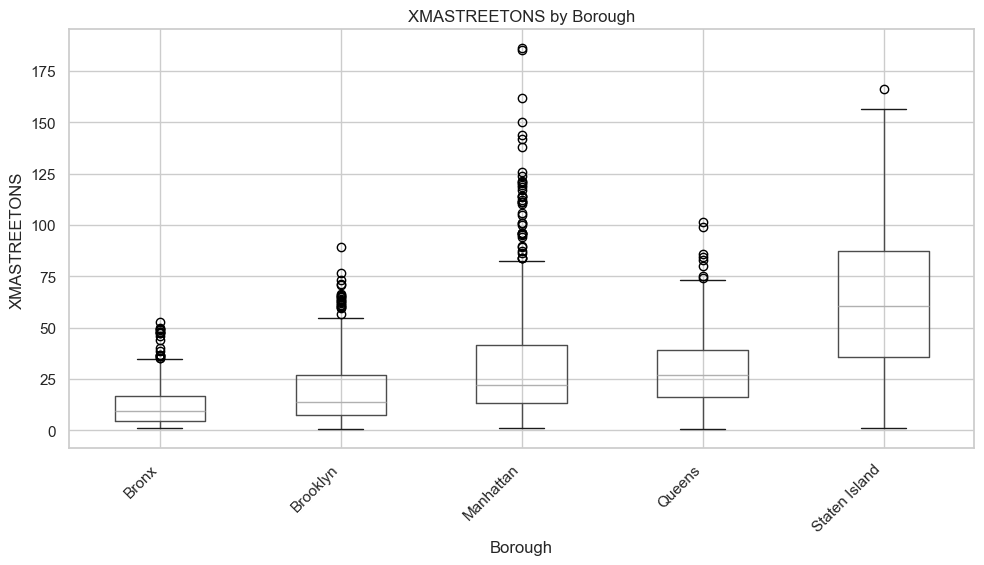

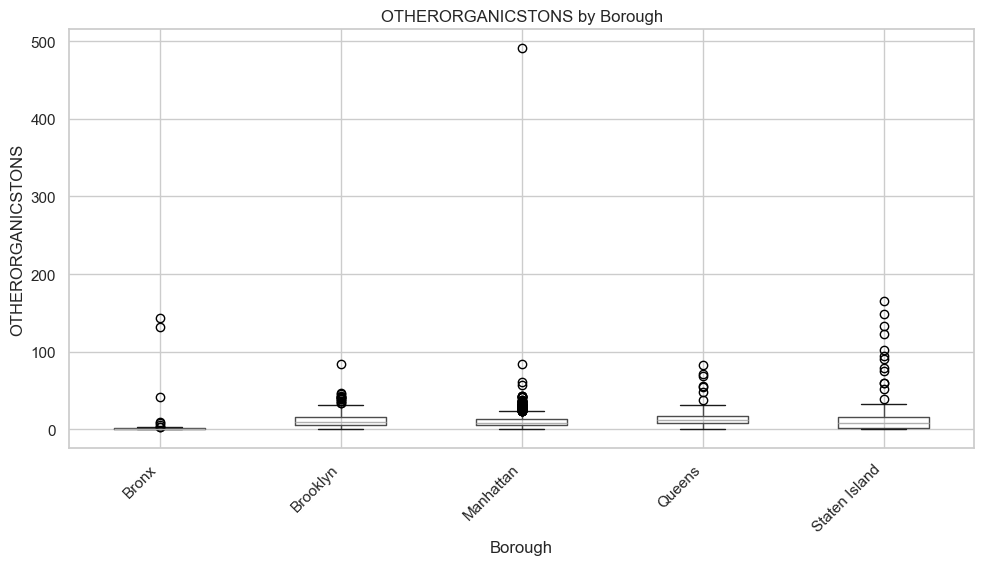

In [101]:
# Box plots grouped by Borough
for col in numerical_cols:
    fig, ax = plt.subplots(figsize=(10, 6))
    df.boxplot(column=col, by='BOROUGH', ax=ax)
    ax.set_title(f'{col} by Borough')
    ax.set_xlabel('Borough')
    ax.set_ylabel(col)
    plt.suptitle('')  # Remove automatic title
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

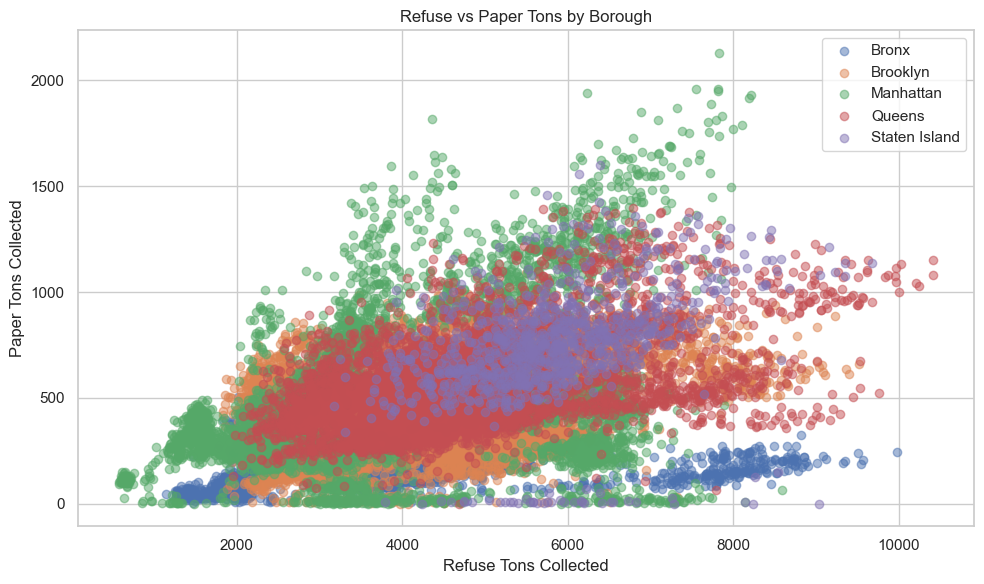

In [102]:
# Color-coded scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
for borough in df['BOROUGH'].unique():
    subset = df[df['BOROUGH'] == borough]
    ax.scatter(subset['REFUSETONSCOLLECTED'], 
               subset['PAPERTONSCOLLECTED'],
               label=borough, alpha=0.5)
ax.set_xlabel('Refuse Tons Collected')
ax.set_ylabel('Paper Tons Collected')
ax.set_title('Refuse vs Paper Tons by Borough')
ax.legend()
plt.tight_layout()
plt.show()

## Categorical vs Numerical

The color-coded scatter plot of Refuse vs Paper tons by Borough shows 
that different boroughs occupy different ranges. Brooklyn and Queens 
tend to have higher tonnage values, reflecting their larger populations 
and number of community districts.